En terapia con protones, un haz monoenergetico de protones de energia $E_{0} ∼ 70–250 MeV$ incide sobre un paciente, modelado aqui como un fantoma de agua. A diferencia de los
fotones, los protones depositan su dosis con un maximo muy localizado al final de su recorrido (el pico de Bragg), lo que permite concentrar la dosis en el tumor minimizando el dano al tejido sano. El objetivo es construir un simulador Monte Carlo del transporte de protones en agua y caracterizar el pico de Bragg.

a) Explique con sus palabras y con las ecuaciones correspondientes los siguientes cuatro conceptos:

1) Pico de Bragg: forma de la curva de dosis depositada $D(z)$ y por que presenta un maximo localizado al final del recorrido. 

El pico de Bragg aparece cuando una particula cargada atraviesa un material e interactua con los electrones del medio, de modo que la energia cinetica disminuye a medida que avanza. Entonces, su velocidad va decreciendo provocando asi que la particula este mas tiempo bajo la influencia del campo electrico de los electrones. Como consecuencia, la energia que pasa al medio aumenta conforme la particula va frenando y, antes de detenerse, esta deposita una gran cantidad de energia en una region pequeña, generando asi un maximo en la energia depostada, formando asi el pico de Bragg.

2) Ecuacion de Bethe–Bloch: perdida de energia por unidad de longitud de una particula cargada en un medio:

$-\frac{dE}{dx}=Kz^{2}\frac{Z}{A}\frac{1}{\beta^{2}}\left[ \frac{1}{2}\ln{\frac{2m_{e}c^{2}\beta^{2}\gamma^{2}T_{max}}{I^{2}}-\beta^{2}} \right]$

Identifique cada simbolo y explique el origen de los factores $z^{2}$ y $\frac{1}{\beta^{2}}$. En particular, $I$ es el potencial medio de excitacion del medio, una constante caracterıstica del material que parametriza la energıa promedio transferida por colision a los electrones atomicos (para agua, $I\approx 75 eV$). 

Esta ecuacion representa la energia perdida de la particula anteriormente descrita por unidad de distancia recorrida. Donde $E$ es la energia cinetica de la particula, $K$ es una constante asociada a la interaccion electromagnetica, $z$ es la carga de la particula, $Z$ es el numero atomico efectivo del medio, $A$ masa atomica efectiva del medio, $\beta = \frac{v}{c}$ es la velocidad de la particula en unidades de la velocidad de la luz, $\gamma$ es el factor de Lorentz y $T_{max}$ es la energia maxima que la particula puede transferir a un electron en una colision.

El factor $z^{2}$ aparece por la interaccion electromagnetica entre la particula carga y los electrones del medio, y como la energia transferida depende del cuadrado de esta interaccion, tenemos que la energia perdida escalam como $z^{2}$. Por otro lado, el factor $\frac{1}{\beta^{2}}$ incluye los efectos relativistas a esta perdida de energia, indicando asi que una particula con menor velocidad permanece mas tiempo interactuando con los electrones del medio, por lo que transfiere mas energia por unidad de longitud.

3) Energy straggling: fluctuacion estadistica de la perdida de energia. En la aproximacion gaussiana de Bohr:

$\sigma_{E}^{2}=4\pi r_{e}^{2}(m_{e}c^{2})^{2} N_{e} \frac{z^{2}}{\beta^{2}} \Delta x$

Debemos tener en cuenta que las colisiones entre la particula cargada (en este caso protones) y los electrones del medio son procesos aleatorios, es decir, aunque tengamos dos protones con la misma energia, despues de recorrer la misma distancia no tienen por que tener la misma energia final. Sin extrapolamos esto a muchos procesos de este estilo describimos esta coliusion con una dispersion estadistica en la perdida de energia, conocida como energy straggling. Donde, en la aproximacion de Bohr, al considerar un numero de colisiones muy grande se utiliza el Teorema Central del Limite para aproximar la distribucion de la energia perdida por una distribucion normal, donde la media sera la diferencia de energia descrita por la ecuacion de Bethe-Bloch y la varianza es $\sigma_{E}^{2}$.

4) Dispersion Coulombiana multiple: desviacion angular acumulada por colisiones con nucleos. En la aproximacion de Highland:

$\theta_{0}=\frac{13.6 MeV}{\beta cp}z \sqrt{\frac{\Delta x}{X_{0}}} \left[ 1+0.038\ln{\frac{\Delta x}{X_{0}}} \right]$ 

donde $\Delta x$ es el espesor del material recorrido y $X_{0}$ es la longitud de radiacion del material.

Ya hablamos de como se ve afectada la energia del proton. Sin embargo, tambien debemos considerar su desviacion por efecto de interacciones Coulombianas. Cuando el proton interactua con los electrones del medio, tambien interactua con sus respectivos nucleos las cuales desvian la trayectoria de este proton y, dado que el numero de interacciones es muy grande, se produce una desviacion angular acumulada. Notemos que la evolucion de esta depende de $\frac{1}{v}$, lo cual tiene sentido. Mientras mas rapido vaya el proton menos interactua con los electrones del medio y, por consiguiente, menos se desvia.

b) Implemente Bethe–Bloch para protones en agua ($I = 75 eV$) y calcule el rango CSDA. La sigla CSDA (Continuous Slowing Down Approximation, aproximacion de frenado continuo)
corresponde a la distancia total recorrida por el proton hasta detenerse, calculada asumiendo que la perdida de energia es continua y determinista (sin fluctuaciones):

$R_{CSDA}(E_{0})=\int_{0}^{E_{0}} \frac{dE}{(-dE/dx)(E)}$

Compare su resultado para $E_0=50, 150, 250 MeV$ con los valores tabulados en la base de datos PSTAR del NIST (National Institute of Standards and Technology de EE.UU.), que
entrega poderes de frenado y rangos para protones en distintos materiales:
https://physics.nist.gov/PhysRefData/Star/Text/PSTAR.html.



In [19]:
###############################################
#                  Librerias                  #
###############################################

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad                                        #Integrador

###############################################
#                 Parametros                  #
###############################################

#Trabajamos en unidades MeV, por tanto no definimos c^{2}

K=0.307075                                                            #Constante de Bethe 
m_e=0.51099895                                                        #Masa electron
m_p=938.27208816                                                      #Masa proton
z_carga=1                                                                   #Carga del proton
Z_A=0.55509                                                           #Numero atomico efectivo del medio (agua)                                                             #Masa efectiva del medio
I=75e-6                                                               #Potencial medio de excitacion


Queremos definir las funciones que nos serviran para el problema. En particular, notemos lo siguiente:

$E_{total}= \gamma mc^{2}  \qquad ;\qquad E_{total}=E_{cin}+mc^{2}$ 

Entonces:

$\gamma = 1 + \frac{E}{mc^{2}}$

Y, tambien sabemos que: 

$\gamma =\frac{1}{\sqrt{1-\beta^{2}}} \qquad \rightarrow \qquad \beta=\sqrt{1-\frac{1}{\gamma^{2}}}$

Por lo cual, tenemos que:

In [20]:
###############################################
#                 Funciones                   #
###############################################

def gamma(E):                                             #Factor de Lorentz
    return 1 + E/m_p

def beta(E):                                              #v/c
    Gamma=gamma(E)
    return np.sqrt(1-(1/Gamma**2))

Ahora, para la maxima energia transferida por colision se cumple que:

$T_{max}=\frac{2m_{e}c^{2}\beta^{2}\gamma^{2}}{1+2\gamma \frac{m_{e}}{m_{p}}+\left( \frac{m_{e}}{m_{p}}\right)}$ 

Entonces:

In [21]:
def Tmax(E):                                              #Energia maxima transferible en una colision proton-electron
    Beta=beta(E)
    Gamma=gamma(E)
    return (2*m_e*(Beta**2)*(Gamma**2)/(1+2*Gamma*(m_e/m_p)+(m_e/m_p)**2))

def BB(E):                                                #Ecuacion de Bethe-Bloch
    Beta=beta(E)
    Gamma=gamma(E)
    TMAX=Tmax(E)
    Arg=(2*m_e*(Beta**2)*(Gamma**2)*TMAX)/(I**2)          #Argumento de ln()
    En=K*(z_carga**2)*Z_A*(1/Beta**2)*((1/2)*np.log(Arg)-Beta**2)

    return En

###############################################
#                Rango CSDA                   #
###############################################

def RangoCSDA(E0):
    E_0=1e-2                                                  #Defino una energia minima de integracion ya que con E=0 tenemos problemas numericos de indeterminacion
    Integrando=lambda E: 1/BB(E)                              #Mantengo E fijo con lambda
    Rango, error=quad(Integrando, E_0, E0, limit=300)                #Integramos
    return Rango

###############################################
#           Rango para 3 energias             #
###############################################

Energias=[50, 150, 250]

for E in Energias:
    R=RangoCSDA(E)
    print(f"{E:<12.1f} {R:<15.4f}")

50.0         2.2221         
150.0        15.7672        
250.0        37.9313        


C:\Users\A23\AppData\Local\Temp\ipykernel_9412\605086086.py:22: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  Rango, error=quad(Integrando, E_0, E0, limit=300)                #Integramos


El warning que aparece es por que quad tiene dificultad en integrar para valores muy abjos de la energia. Sin embargo, si comparamos estos resultados con los valores tabulados en la base de datos de PSTAR del NIST, tenemos que:

-$E=50 \rightarrow CSDA=2.227$ 

-$E=150 \rightarrow CSDA=15.77$ 

-$E=250 \rightarrow CSDA=37.94$ 

Entonces, el error asociado es de:

In [22]:
Energias=np.array([50, 150, 250])                                          #Energias utilizadas
R_modelo=np.array([2.2221, 15.7672, 37.9313])                              #Rango obtenido por el modelo
R_PSTAR=np.array([2.2270, 15.7700, 37.9400])                               #Rango tabulados por PSTAR
Error=np.abs(R_modelo - R_PSTAR) / R_PSTAR * 100                           #Error relativo porcentual

print(f"{'Energía (MeV)':<15} {'Modelo (cm)':<15} {'PSTAR (cm)':<15} {'Error (%)':<12}")
print("-"*60)

for E, Rm, Rp, Err in zip(Energias, R_modelo, R_PSTAR, Error):
    print(f"{E:<15.0f} {Rm:<15.4f} {Rp:<15.4f} {Err:<12.4f}")

Energía (MeV)   Modelo (cm)     PSTAR (cm)      Error (%)   
------------------------------------------------------------
50              2.2221          2.2270          0.2200      
150             15.7672         15.7700         0.0178      
250             37.9313         37.9400         0.0229      


c) Simule el transporte de $N=10^4$ protones con $E_0=150 MeV$, en pasos $\Delta x=0.1 mm$, restando en cada paso $\Delta E = -\frac{dE}{dx} \Delta x $ (sin fluctuacion). Grafique la dosis depositada $D(z)$, identifique el pico de Bragg y verifique que su posicion coincide con RCSDA obtenido en (b). 

Como no tenemos fluctuacion, los protones no se desvian, entonces:

$E_{n+1}=E_{n}-\Delta E_{n}$

C:\Users\A23\AppData\Local\Temp\ipykernel_9412\605086086.py:22: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  Rango, error=quad(Integrando, E_0, E0, limit=300)                #Integramos


Posición del pico de Bragg=15.7800 cm
Rango CSDA para 150 MeV   =15.7672 cm


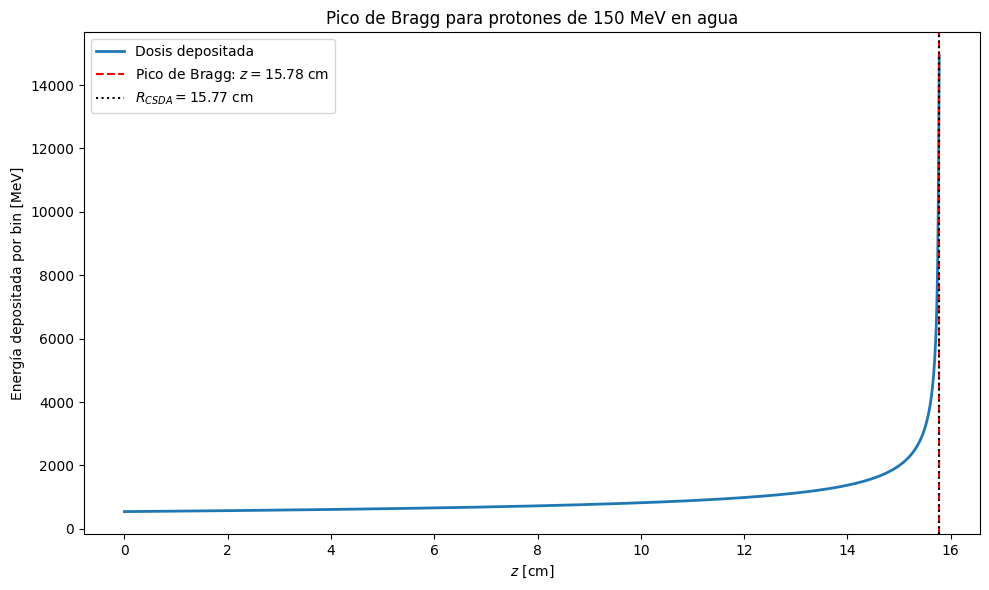

In [ ]:
###############################################
#             Parametros fisicos              #
###############################################

E=150
R_CSDA=RangoCSDA(E)
N_p=10000                                        #Numero de protones
dx=0.01                                          #paso
 
z_val=[]                                         #Guarda posicion
D_val=[]                                         #Guarda energia transferida 
              
#Condicion inicial

z_pos=0

E_min=1e-2

while E > E_min:
    S=BB(E)
    dE=S*dx                                      #Energia perdida en cada paso

    if dE > E:                                   #Establece una cota para la energia disponible
        dE=E

    z_val.append(z_pos)
    D_val.append(N_p*dE)

    E=E-dE                                       #Actualizamos energia y posicion
    z_pos=z_pos+dx

#Convierto en arreglos las listas para identificar peak

z_vals=np.array(z_val)                         
D_vals=np.array(D_val)

peak=np.argmax(D_val) 
z_peak=z_val[peak]                               #Tomo el valor de z en el peak            
D_peak=D_val[peak]                               #Tomo el valor de D(z) en el peak

print(f"Posición del pico de Bragg={z_peak:.4f} cm")
print(f"Rango CSDA para 150 MeV   ={R_CSDA:.4f} cm")

###############################################
#                    Grafica                  #
###############################################

plt.figure(figsize=(10, 6))

plt.plot(z_val, D_val, lw=2, label="Dosis depositada")
plt.axvline(z_peak, color="r", linestyle="--", label=fr"Pico de Bragg: $z={z_peak:.2f}$ cm")
plt.axvline(R_CSDA, color="k", linestyle=":", label=fr"$R_{{CSDA}}={R_CSDA:.2f}$ cm")
plt.xlabel("$z$ [cm]")
plt.ylabel("Energía depositada por bin [MeV]")
plt.title("Pico de Bragg para protones de 150 MeV en agua")
plt.legend()
plt.tight_layout()
plt.show()


Notamos que efectivamente la posicion del pico de Braggs coincide con $R_{CSDA}$.

d) Repita (c) incorporando la fluctuacion estadistica en cada paso:

$\Delta E \thicksim \mathcal{N}(\langle \Delta E \rangle, \sigma_{E}^{2})$

Compare $D(z)$ con y sin straggling, y mida el ensanchamiento $\sigma_{R}$ del pico. Discuta brevemente la relevancia clinica de este ensanchamiento.



Rango medio con straggling=14.8238 cm
Ensanchamiento sigma_R    =0.2892 cm


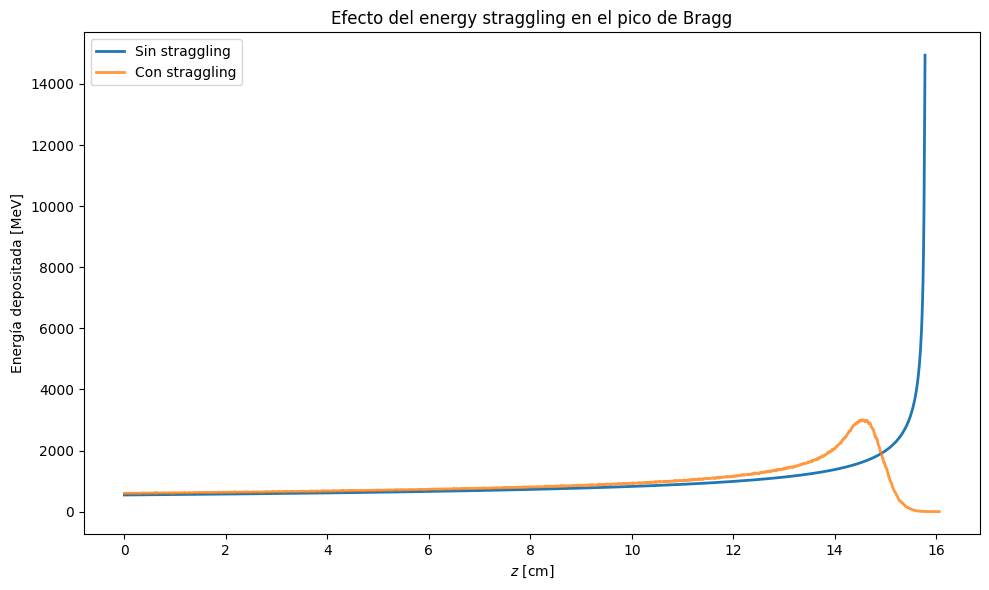

In [ ]:
###############################################
#           Energy straggling                 #
###############################################

N_A=6.02e23                                                     #Numero de Avogadro
r_e=2.82e-13                                                    #radio electron
N_e=N_A*Z_A                                                     #Densidad efectiva de los electrones en el medio (consideramos densidad del agua = 1)
E=150
E_min=0.1                                                       #Establezco una cota inferior mas grande, porque el codigo no compilaba

def sigma(E,dx):
    Beta=beta(E)
    return np.sqrt(4*np.pi*(r_e**2)*(m_e**2)*N_e*(z_carga**2)/(Beta**2)*dx)

#Establecemos una semilla

np.random.seed(42)

E_protones=np.ones(N_p)*E                              #Energia inicial de todos los protones

D_str=[]                                               #Guarda energia transferida
z_str=[]                                               #Guarda posicion

rangos_finales=np.zeros(N_p)                           #Aqui guardamos las posiciones finales

z_pos=0
paso=0

while np.any(E_protones>E_min):
    vivos=E_protones > E_min                         #Seleccion de protones que se siguen moviendo
    E_vivos=E_protones[vivos]
    dE_media=BB(E_vivos)*dx                          #Perdida media de energia
    sigma_E=sigma(E_vivos, dx)                       #Desviacion estandar del straggling 
    dE=np.random.normal(dE_media, sigma_E)           #Perdida aleatoria de energia
    dE=np.maximum(dE, 0)                             #Evitaperdidas negativas
    dE = np.minimum(dE, E_vivos)                     #Cota de perdida de energia
    D_str.append(np.sum(dE))
    z_str.append(z_pos)

    E_protones[vivos]=E_vivos-dE                 #Actualizamos energias

    detenidos=vivos.copy()
    detenidos[vivos]=E_protones[vivos]<=E_min
    rangos_finales[detenidos]=z_pos

    z_pos+=dx
    paso+=1

z_strag=np.array(z_str)
D_strag=np.array(D_str)

###############################################
#          Ensanchamiento del pico            #
###############################################

sigma_R=np.std(rangos_finales)                                 #Rango medio alcanzado por los protones
R_medio=np.mean(rangos_finales)                                #Ensanchamiento del pico de Braggs

print(f"Rango medio con straggling={R_medio:.4f} cm")
print(f"Ensanchamiento sigma_R    ={sigma_R:.4f} cm")

###############################################
#        Comparacion con y sin straggling     #
###############################################

plt.figure(figsize=(10, 6))
plt.plot(z_vals, D_vals, lw=2, label="Sin straggling")
plt.plot(z_strag, D_strag, lw=2, label="Con straggling", alpha=0.8)
plt.xlabel("$z$ [cm]")
plt.ylabel("Energía depositada [MeV]")
plt.title("Efecto del energy straggling en el pico de Bragg")
plt.legend()
plt.tight_layout()
plt.show()

Notemos que la incorporacion del energy straggling produce un ensanchamiento del pico de Bragg, disminuyendo su amplitud maxima y ensanchando el deposito de energia. El efecto clinico es relevante ya que la dosis maxima deja de concentrarse sobre una region reducida y comienza a distribuirse sobre un volumen mayor. Como consecuencia, en terapia con protones debemos considerar este efecto para que el proceso no sea dañino.